# Experiments Notebook — *Feature Relevancy, Necessity and Usefulness*

This notebook is a guide to the **entire** experimentation from the corrected, tested
engine in [`experiments.py`](experiments.py):

1. Feature usefulness qualitative analysis;
2. Comparison against SHAP, permutation importance, LIME, Integrated Gradients and MDI;
3. Runtime & memory analysis;
4. Binning strategy sensitivity (uniform / quantile / kmeans).

The heavy code lives in the module (so it stays tested and reusable); the cells below
are a thin, readable layer that calls it and shows each table/figure inline.

**How to use:** edit `DATASET` / `N_MODELS` in the setup cell, then *Run All*.
Bike Sharing runs fully offline; California and Adult download their public datasets
on first use. Everything is seeded, so re-runs are identical.

In [ ]:
# Make the engine importable whether this notebook sits in extensions/ or the repo root.
import os, sys, warnings
warnings.filterwarnings('ignore')
for _cand in (os.getcwd(), os.path.join(os.getcwd(), 'extensions')):
    if os.path.exists(os.path.join(_cand, 'experiments.py')):
        sys.path.insert(0, _cand); break
import experiments as ux
from IPython.display import Image, display

# ---- experiment settings (edit these) ----
DATASET    = 'bike_sharing'   # 'california' | 'bike_sharing' | 'adult_income'
N_MODELS   = 10               # trees per configuration (the paper uses 20)
INCLUDE_IG = True             # Integrated Gradients is the slow method; set False to skip it
RESULTS    = 'results'        # where CSVs and figures are written
os.makedirs(RESULTS, exist_ok=True)

ux.set_all_seeds(42)
ux.set_plot_style()
cfg = ux.Config(n_models=N_MODELS)

METHODS = ('usefulness', 'mdi', 'permutation', 'shap', 'lime')
if INCLUDE_IG:
    METHODS = METHODS + ('integrated_gradients',)

TAG = os.path.join(RESULTS, DATASET)   # output filename prefix for this dataset
def show(path_no_ext, width=None):     # display a saved figure inline
    display(Image(filename=path_no_ext + '.png', width=width))

print(f'dataset={DATASET}  n_models={N_MODELS}  methods={METHODS}')

dataset=bike_sharing  n_models=10  methods=('usefulness', 'mdi', 'permutation', 'shap', 'lime', 'integrated_gradients')


### Sanity check — the tree algebra

The corrected core still reproduces every known-answer count from the paper's test cell
(model counting, negation, conjunction, conditioning, and the domain-minimum fix).

In [21]:
ux.run_tree_tests()

run_tree_tests: all assertions passed


### A fixed bug worth seeing: the `season` domain

The original paper declared the Bike features `season` / `weathersit` over the domain
`(0, 1)` / `(0, 4)`, but their real values are **1–4**. With the wrong domain,
`season`'s usefulness score collapses to **0** (last place).
The fix (`correct_categorical_domains=True`, the default) restores it.
*(Only meaningful for Bike Sharing.)*

In [24]:
if DATASET == 'bike_sharing':
    for corrected in (False, True):
        b = ux.train_tree('bike_sharing', bins=6, strategy='quantile', seed=420,
                          leaves=600, correct_categorical_domains=corrected)
        sc = dict(zip(b.features, ux.usefulness_scores(b.clf, b.domains, b.features)))
        rank = [f for f, _ in sorted(sc.items(), key=lambda t: -t[1])]
        label = 'corrected (1..4)' if corrected else 'original (0,1)/(0,4)'
        print(f'{label:22s} season score = {sc["season"]:.3e}   rank = {rank.index("season")+1}/{len(rank)}')
else:
    print('Skip: this demo is specific to Bike Sharing.')

original (0,1)/(0,4)   season score = 0.000e+00   rank = 12/12
corrected (1..4)       season score = 1.114e+07   rank = 3/12


## 1. Feature usefulness qualitative analysis

Train `N_MODELS` trees per bin count and aggregate each feature's usefulness score
(median bar, Q1–Q3 whiskers) together with the mean model accuracy.

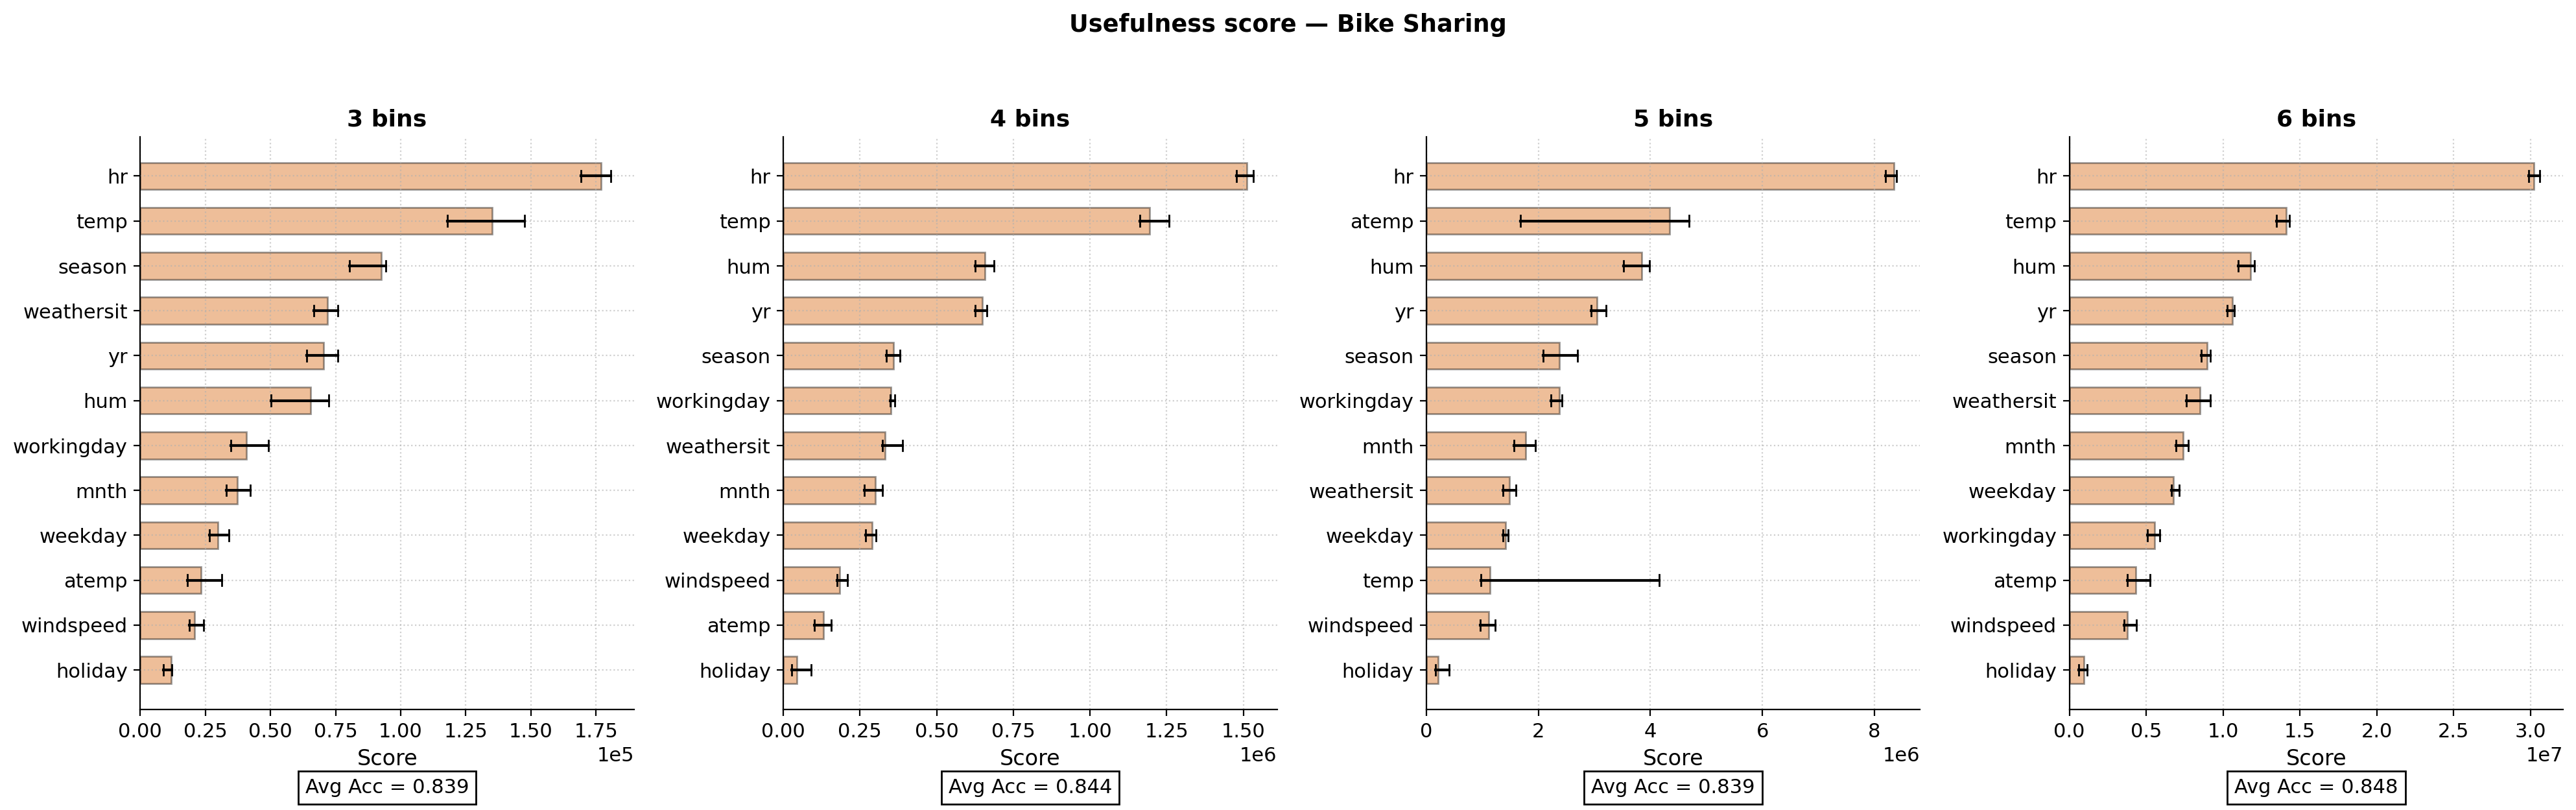

,dataset,strategy,bins,feature,q1,median,q3,mean_accuracy
0,bike_sharing,uniform,3,holiday,8947.00,11781.0,12048.50,0.838751
1,bike_sharing,uniform,3,windspeed,18738.75,20937.0,24371.25,0.838751
2,bike_sharing,uniform,3,atemp,18005.25,23424.0,31189.50,0.838751
3,bike_sharing,uniform,3,weekday,26643.75,29821.5,34045.50,0.838751
4,bike_sharing,uniform,3,mnth,33101.25,37207.5,42357.00,0.838751
5,bike_sharing,uniform,3,workingday,34690.50,40721.0,49136.50,0.838751
6,bike_sharing,uniform,3,hum,50086.50,65392.5,72382.50,0.838751
7,bike_sharing,uniform,3,yr,63998.00,70356.0,75844.50,0.838751
8,bike_sharing,uniform,3,weathersit,66673.00,71764.0,75880.00,0.838751
9,bike_sharing,uniform,3,season,80318.00,92524.0,94385.00,0.838751


In [23]:
scores = ux.run_score_experiment(DATASET, cfg, strategy='uniform')
ux.plot_scores(scores, DATASET, f'{TAG}_usefulness_scores')
show(f'{TAG}_usefulness_scores')
scores['table'].head(12)   # per-feature quartiles (tidy table, also saved to CSV)

## 2. Comparison with other importance methods

Compute every method on the **same** trees and compare the *rankings* they induce:
a normalized-importance heatmap, pairwise rank correlation, top-k overlap with the
usefulness ranking, and agreement with the domain ground-truth ranking stated in the paper.

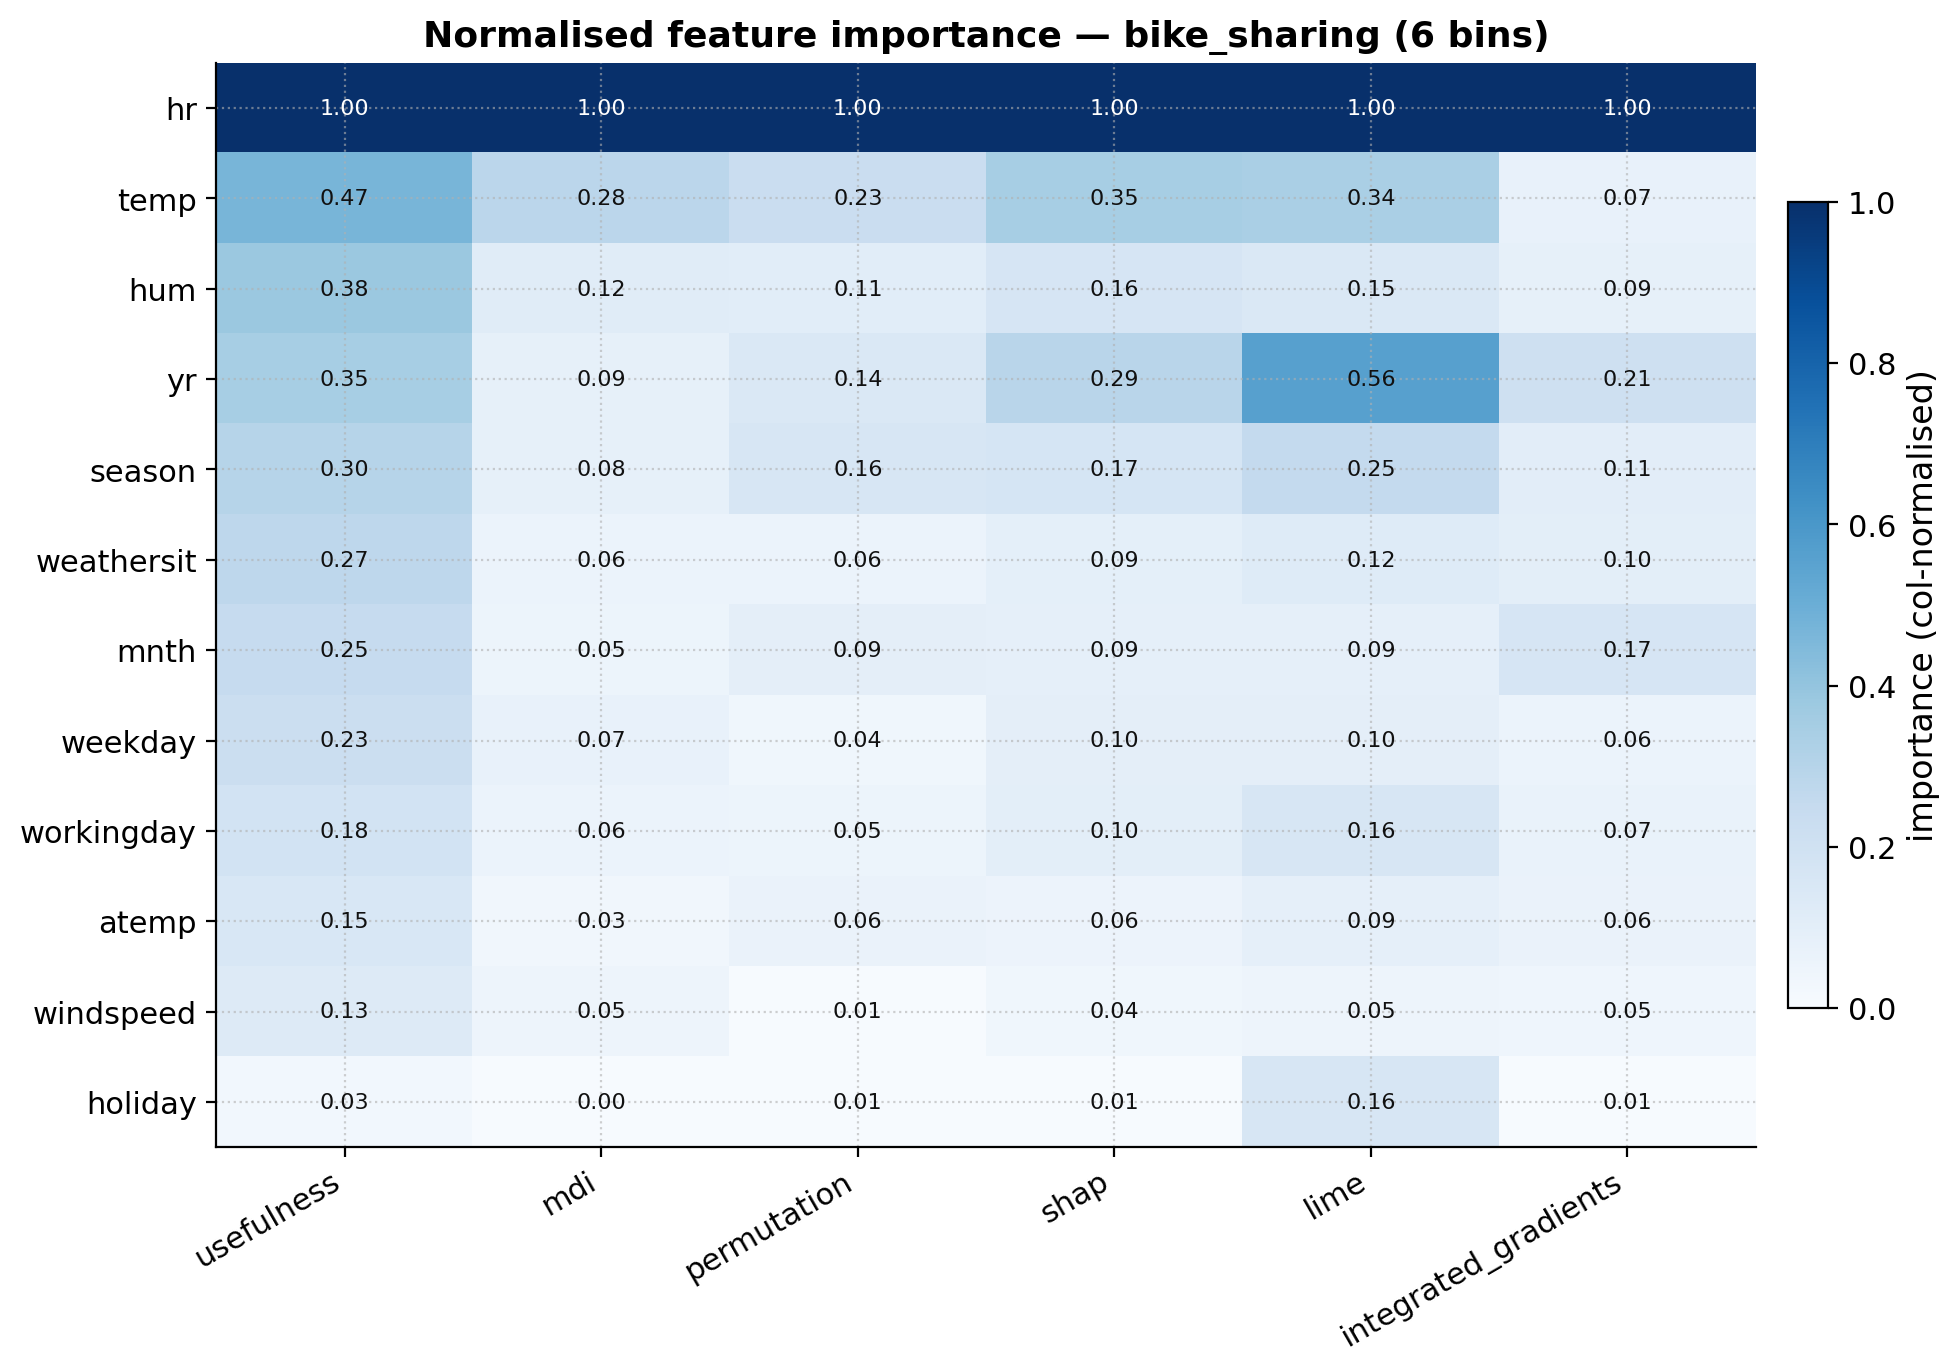

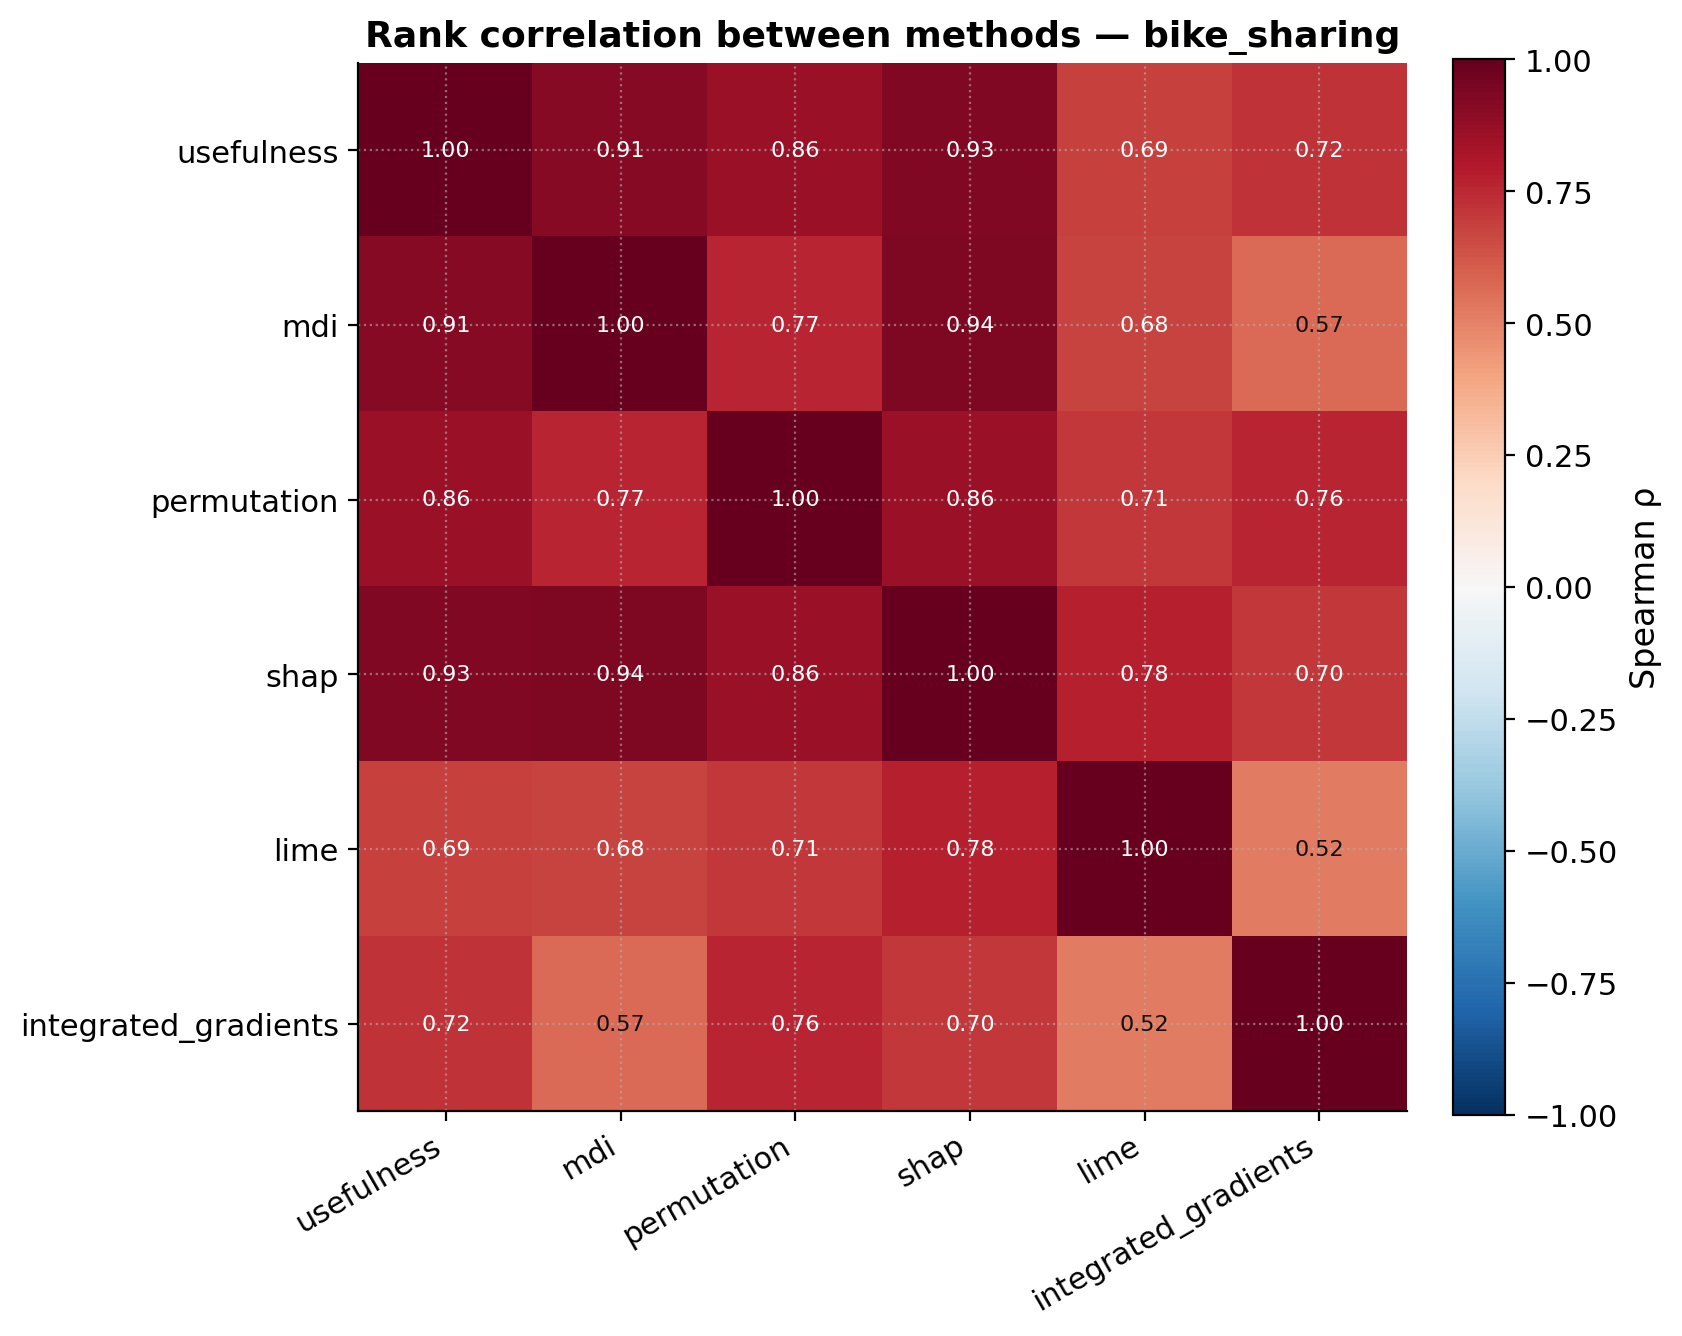

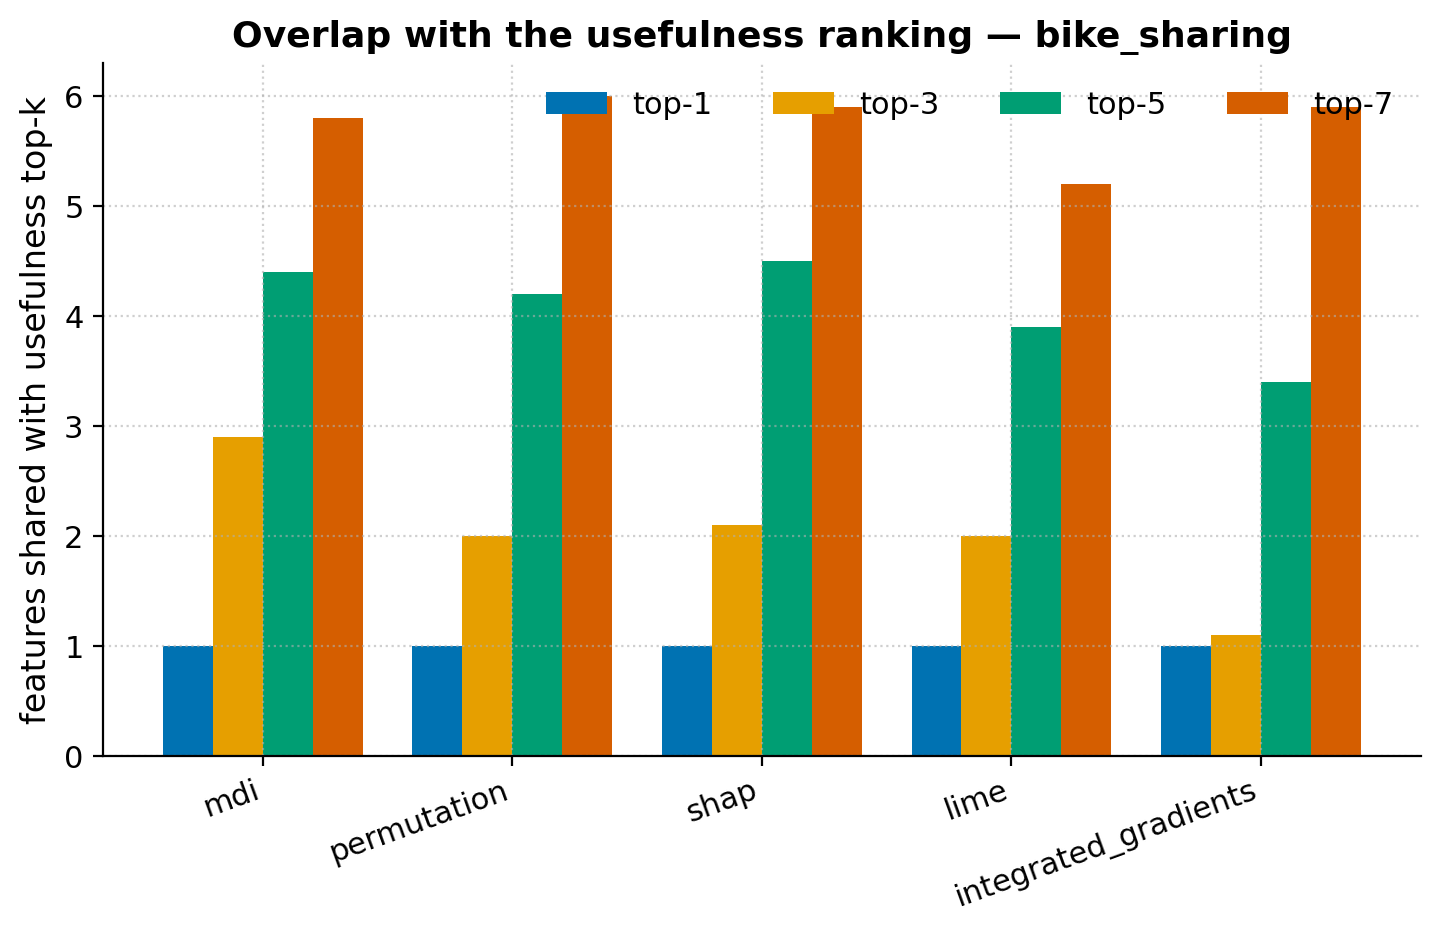

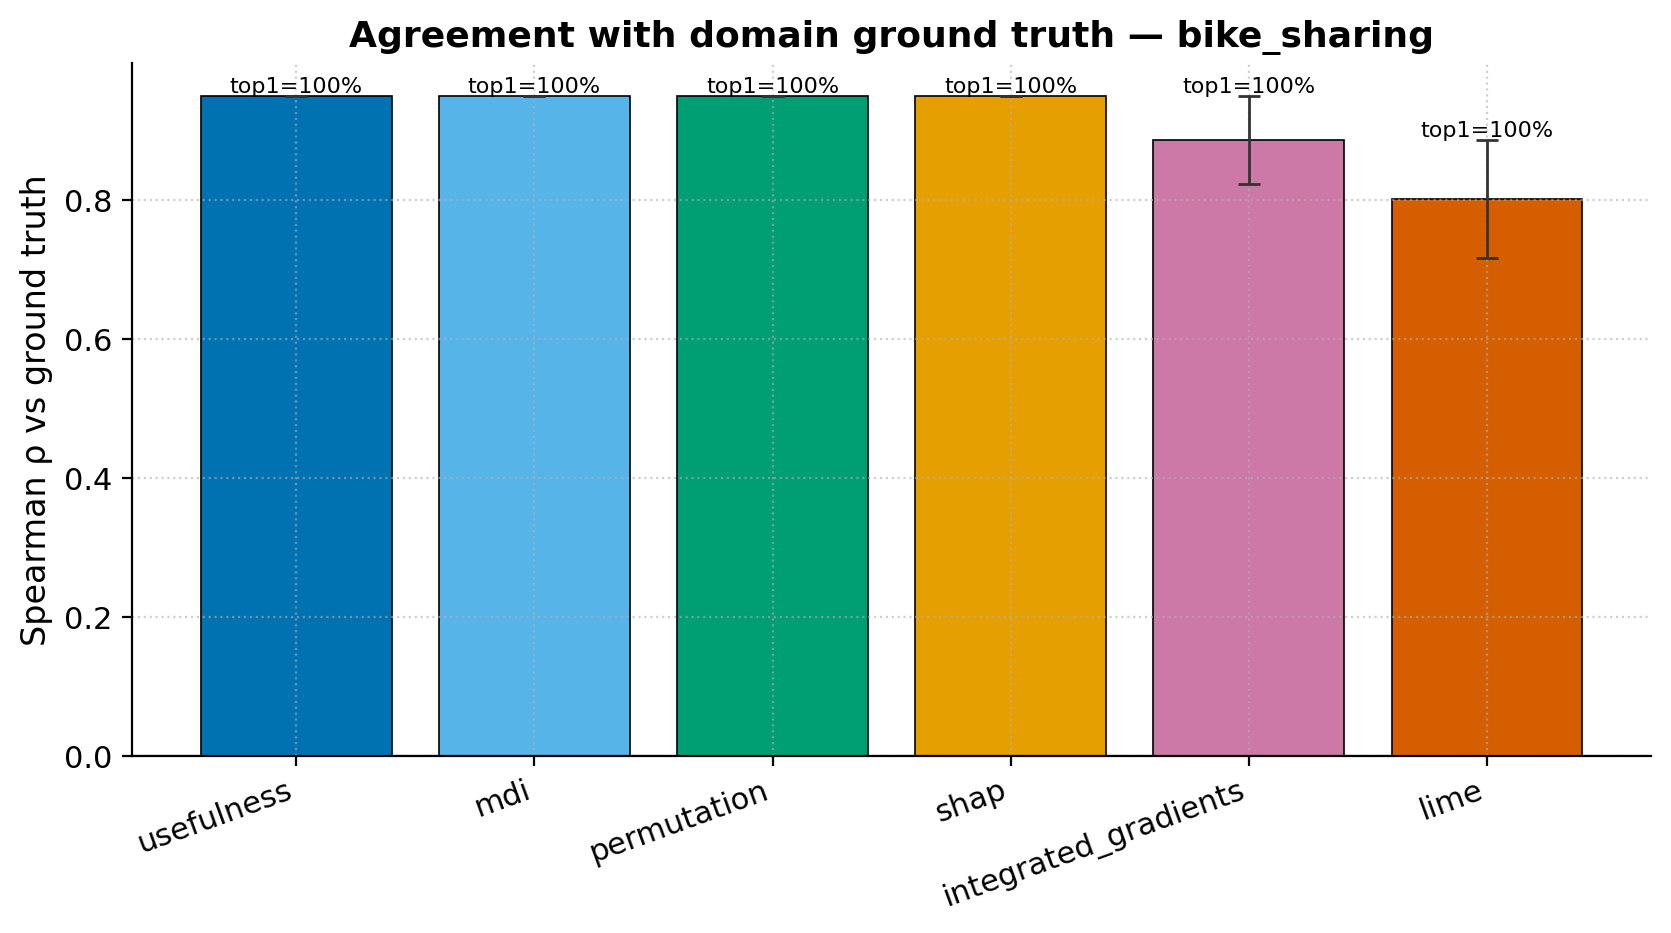

Ground-truth agreement (mean + 95% bootstrap CI over the models):


,mean,ci_lo,ci_hi
usefulness,0.949,0.949,0.949
mdi,0.949,0.949,0.949
permutation,0.949,0.949,0.949
shap,0.949,0.949,0.949
lime,0.801,0.717,0.885
integrated_gradients,0.885,0.822,0.949


paired Wilcoxon usefulness vs SHAP: p = 1.0 (n = 10 ) rankings identical across models -> no detectable difference


In [25]:
comp = ux.run_comparison_experiment(DATASET, cfg, bins=6, methods=METHODS, n_models=N_MODELS)
for _name, _fn in [('importance_heatmap',      ux.plot_method_importance_heatmap),
                   ('rank_correlation',        ux.plot_rank_correlation_heatmap),
                   ('topk_overlap',            ux.plot_topk_intersection),
                   ('ground_truth_agreement',  ux.plot_ground_truth_agreement)]:
    _fn(comp, f'{TAG}_{_name}')
    show(f'{TAG}_{_name}')
print('Ground-truth agreement (mean + 95% bootstrap CI over the models):')
display(comp['gt_ci'].round(3))
w = comp['wilcoxon'].get('usefulness_vs_shap', {})
print('paired Wilcoxon usefulness vs SHAP: p =', round(w.get('p', float('nan')), 4),
      '(n =', w.get('n'), ')', w.get('note', ''))

## 3. Runtime & memory analysis

How the usefulness algorithm scales with the number of bins and the tree size
(time via `perf_counter`, peak memory via the stdlib `tracemalloc`; the tree-size
panel overlays a power-law fit to show empirical complexity), and the wall-clock
cost of every importance method on the same model.

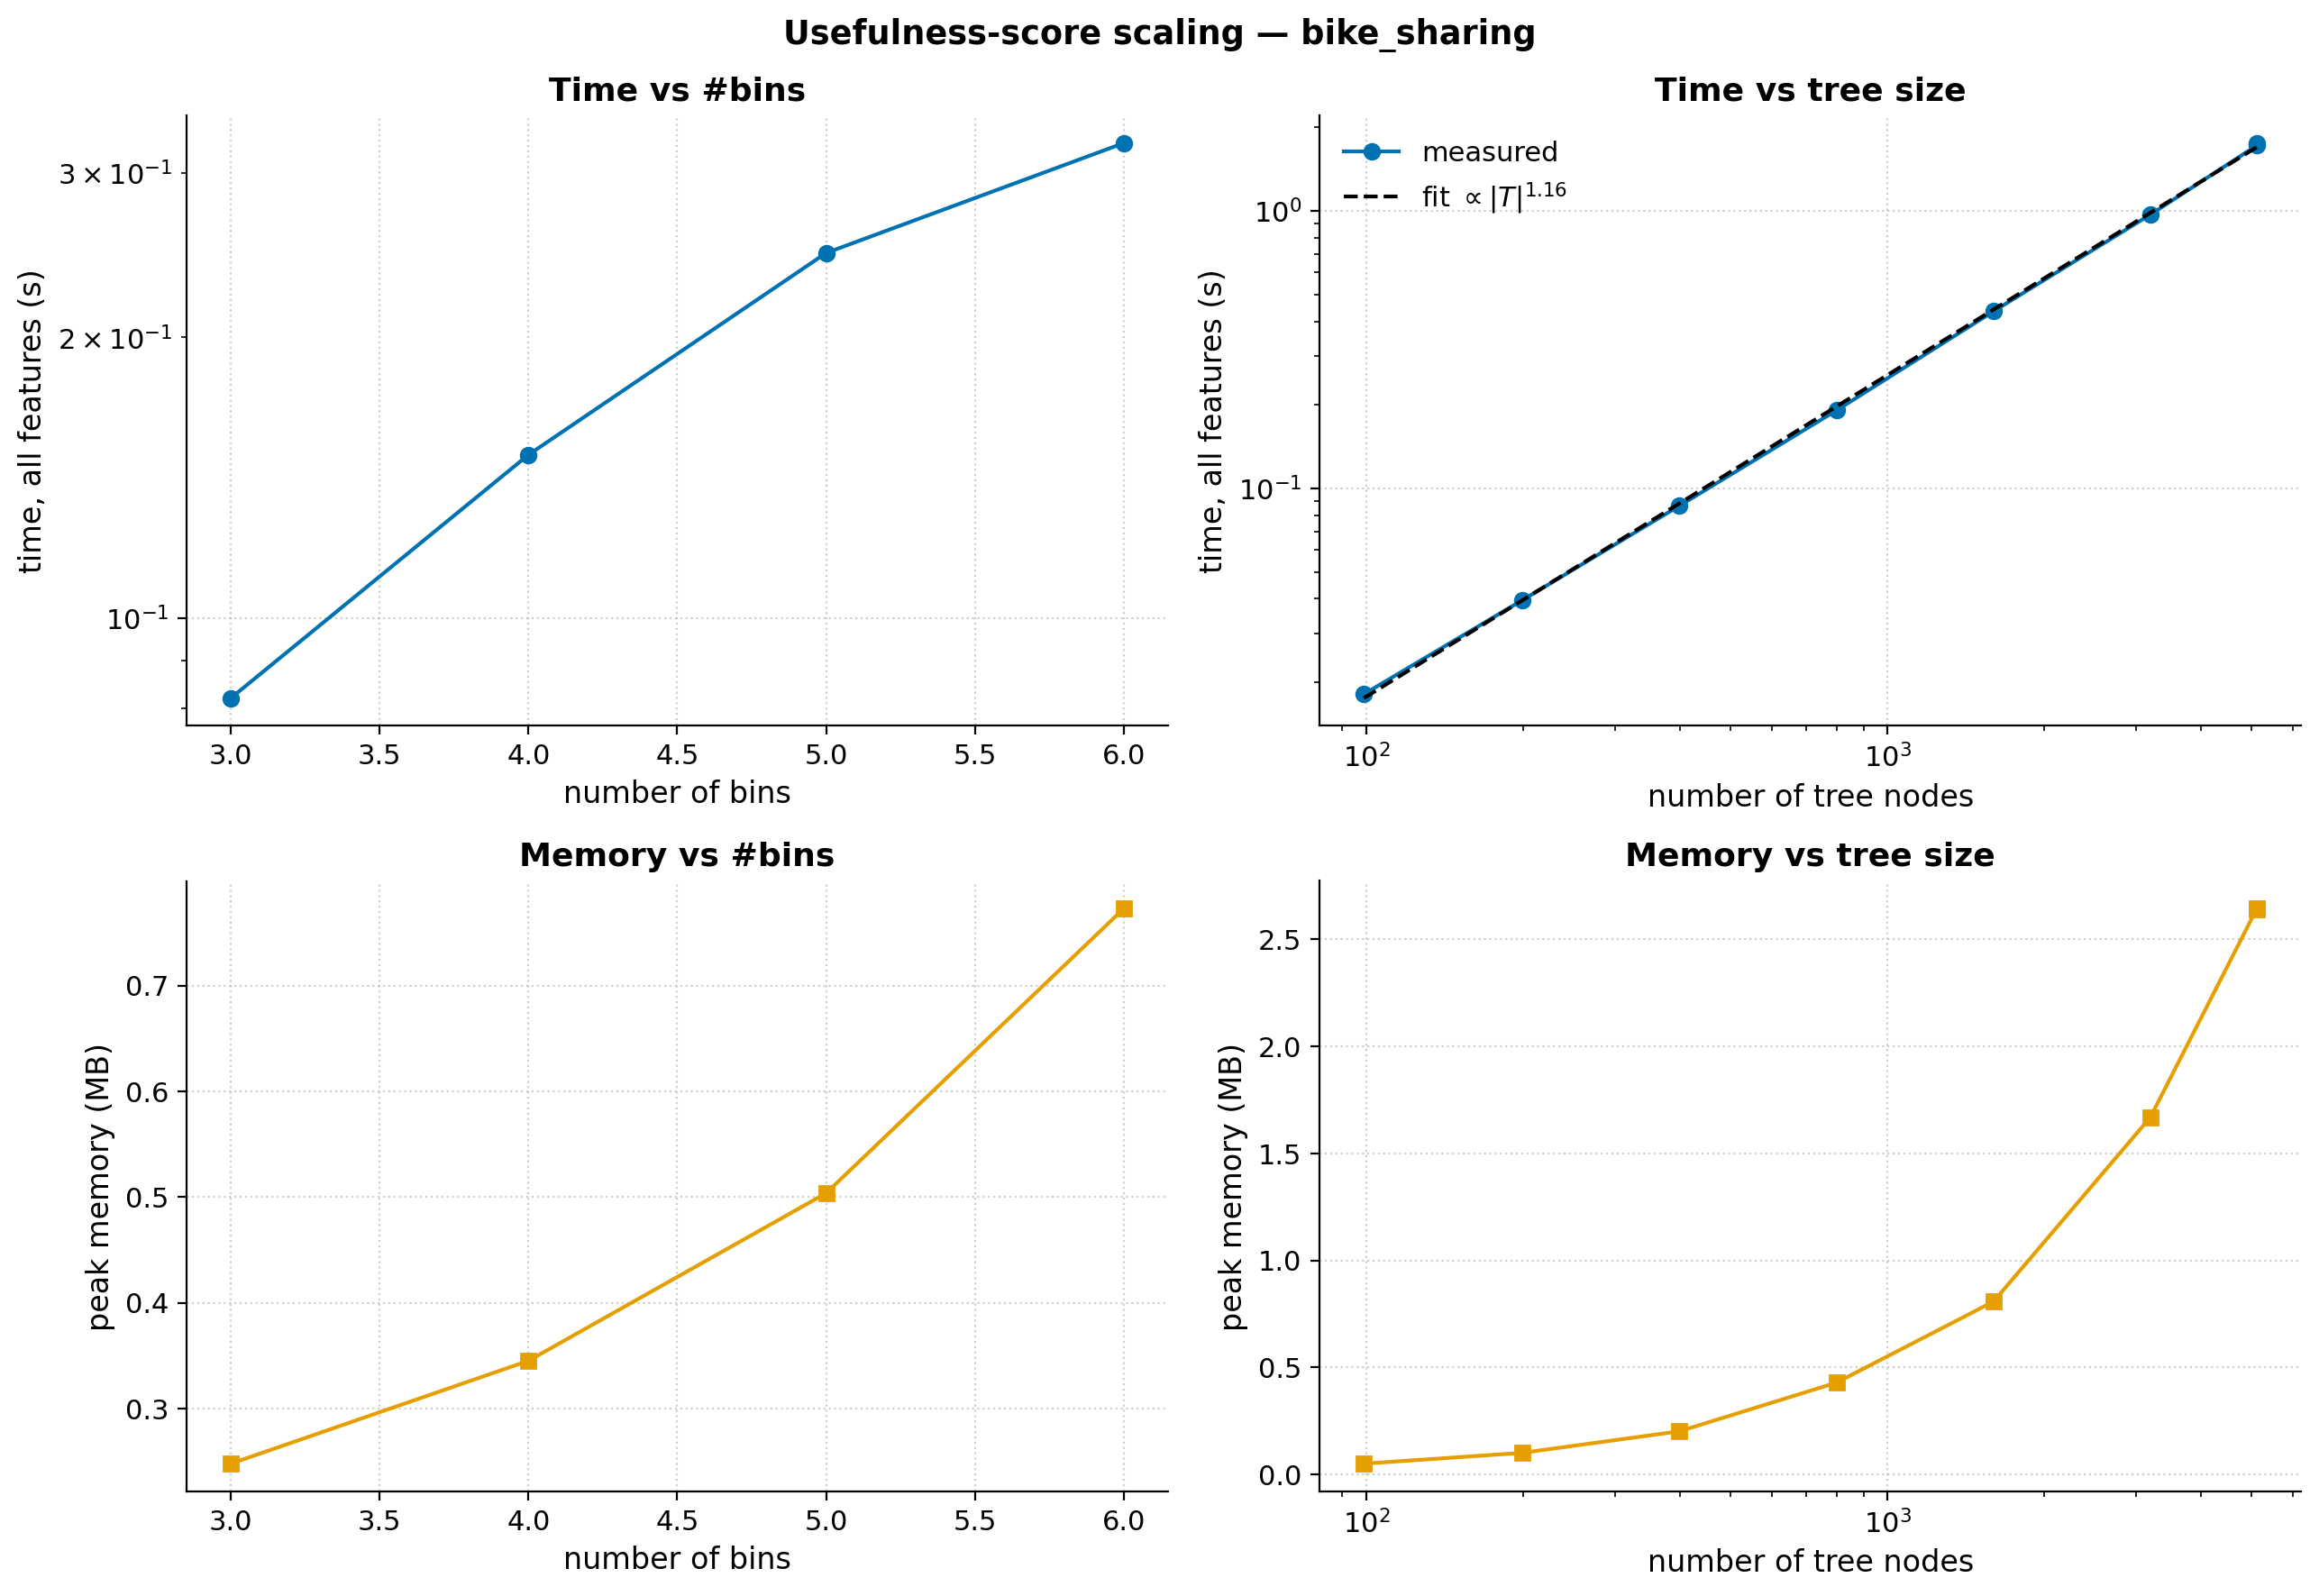

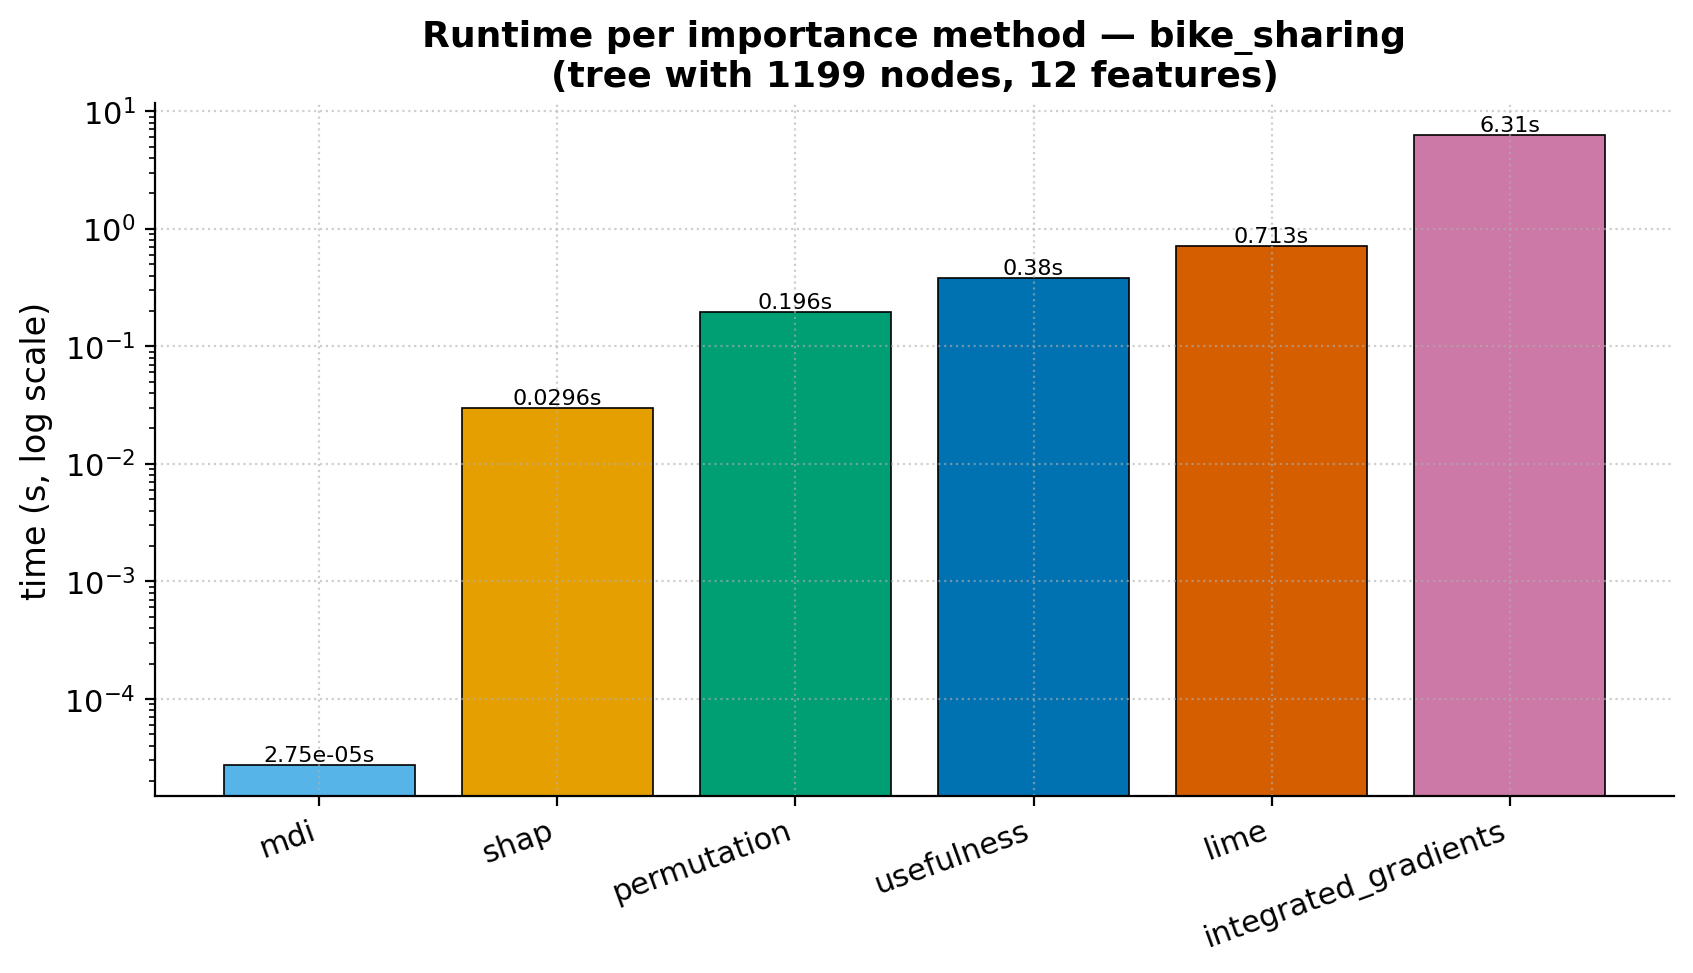

,method,time_s,n_nodes,n_features
0,usefulness,0.379622,1199,12
1,mdi,0.000028,1199,12
2,permutation,0.195926,1199,12
3,shap,0.029612,1199,12
4,lime,0.712588,1199,12
5,integrated_gradients,6.309121,1199,12


In [26]:
scaling = ux.scaling_experiment(DATASET, cfg, strategy='uniform')
ux.plot_scaling(scaling, DATASET, f'{TAG}_scaling')
show(f'{TAG}_scaling')

_leaves = cfg.leaves_per_bin[DATASET] * 6
model = ux.train_tree(DATASET, bins=6, strategy='uniform', seed=42, leaves=_leaves)
runtimes = ux.method_runtime_comparison(model, cfg, methods=METHODS)
ux.plot_method_runtimes(runtimes, DATASET, f'{TAG}_method_runtimes')
show(f'{TAG}_method_runtimes')
runtimes

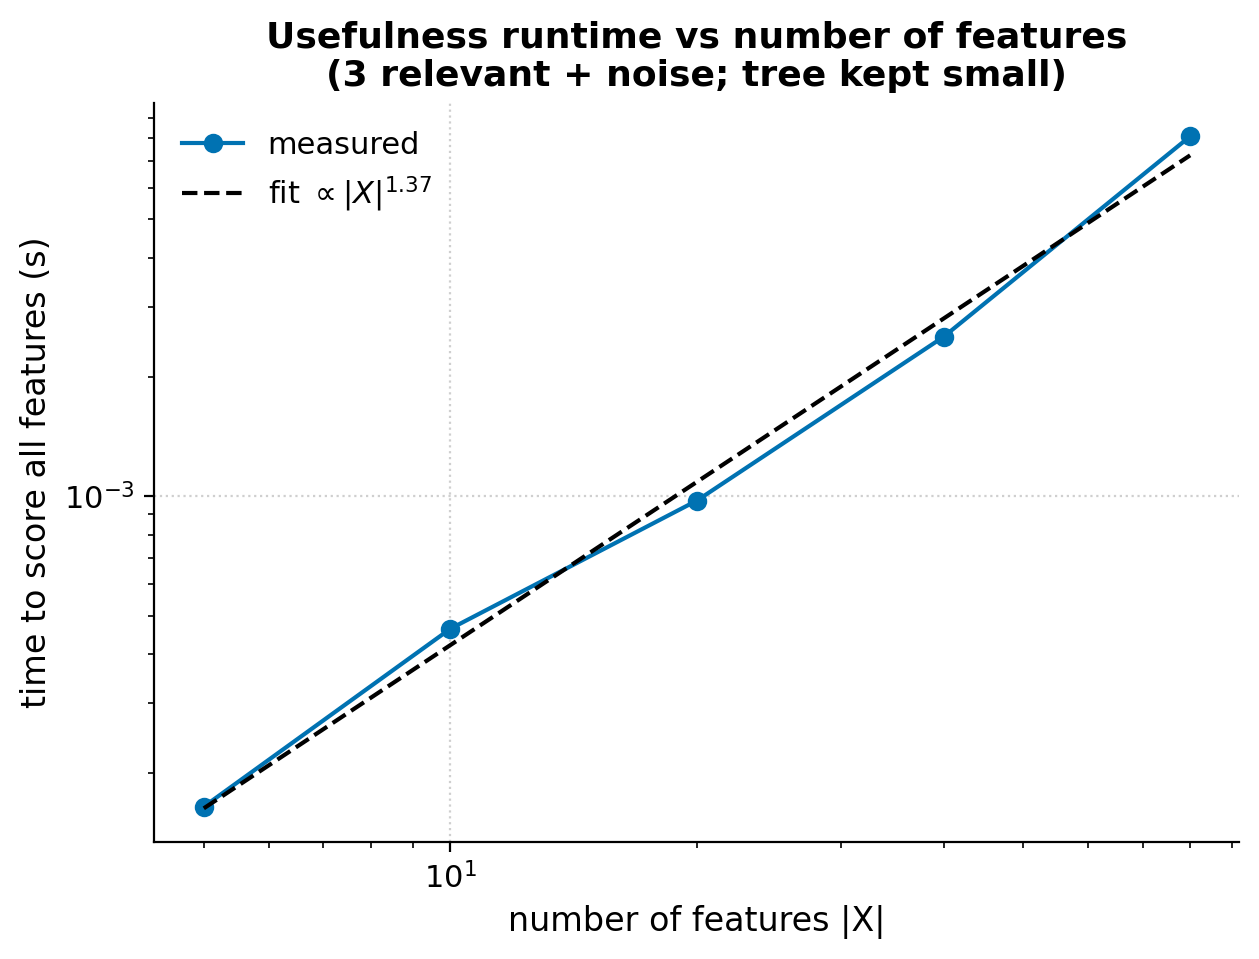

,n_features,n_nodes,time_s,peak_mem_mb
0,5,7,0.000165,0.001930
1,10,7,0.000463,0.002232
2,20,7,0.000975,0.002781
3,40,7,0.002526,0.003567
4,80,7,0.008099,0.005127


In [27]:
# runtime vs number of features (dataset-independent synthetic sweep; answers 2.f-i)
nfeat = ux.runtime_vs_n_features(cfg)
ux.plot_runtime_vs_n_features(nfeat, f'{RESULTS}/runtime_vs_n_features')
show(f'{RESULTS}/runtime_vs_n_features')
nfeat

### A fairer performance picture

The raw runtime bar is a bit unfair to the usefulness score, for measurable reasons:

* **(a)** the prototype spent most of its time in `copy.deepcopy`, not the algorithm —
  a copy-free scorer is ~5x faster with *identical* results;
* **(b)** usefulness reads only the tree, so it is **data-free**: its runtime is flat in
  the number of instances while SHAP / permutation / LIME grow;
* **(c)** the approximate methods look cheap only at a fixed small sample — here is the
  wall-clock each needs before its ranking stabilises;
* **(d)** and the quality-vs-cost (Pareto) view puts it all together.

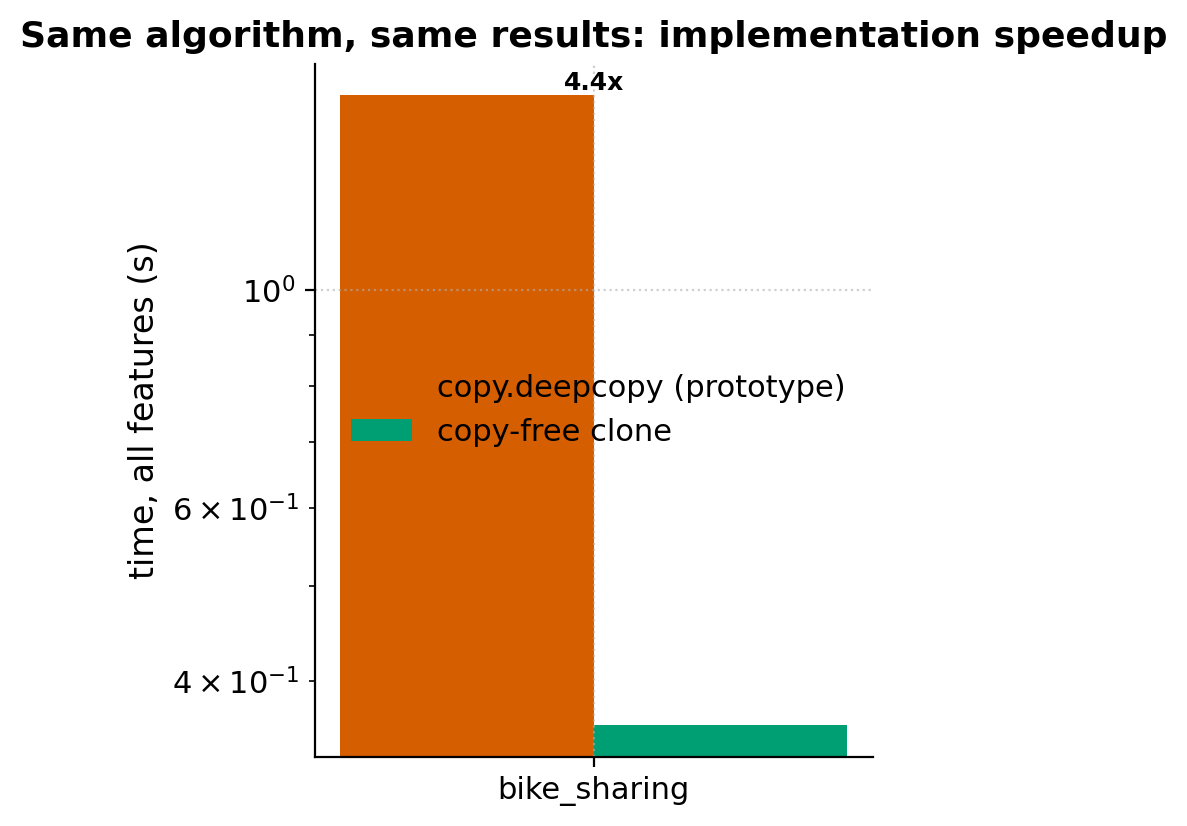

 deepcopy_s  clone_s  speedup
      1.581    0.361     4.38


In [28]:
import pandas as pd
# (a) implementation speedup (same algorithm, identical results)
speedup = pd.DataFrame([ux.profile_scorer_speedup(model)])
ux.plot_scorer_speedup(speedup, f'{TAG}_scorer_speedup'); show(f'{TAG}_scorer_speedup')
print(speedup[['deepcopy_s', 'clone_s', 'speedup']].round(3).to_string(index=False))

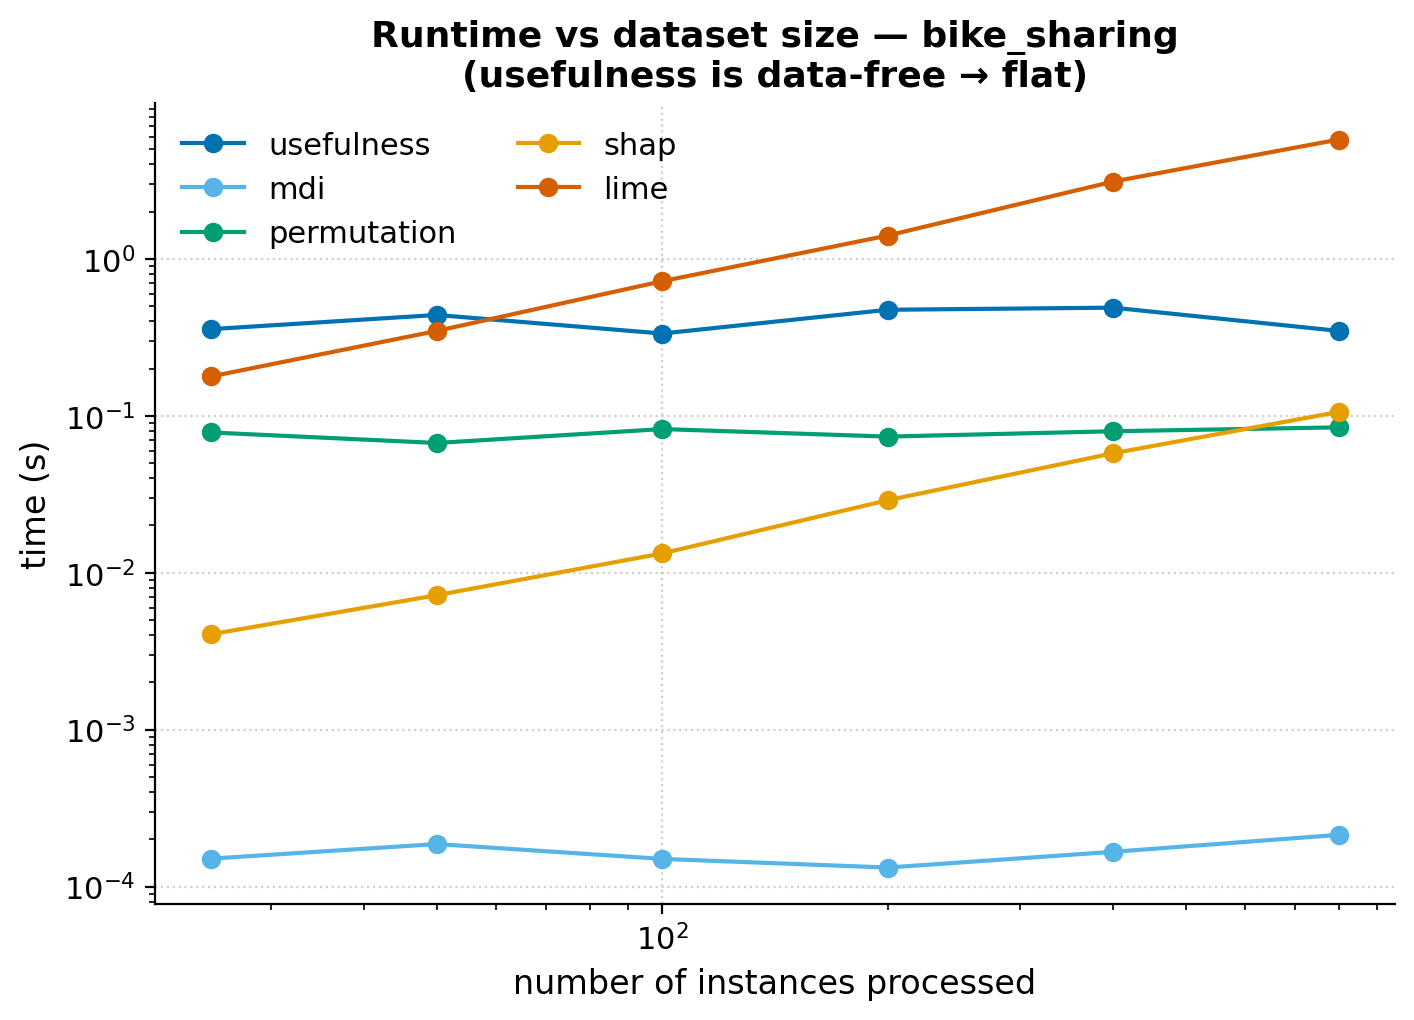

In [29]:
# (b) runtime vs dataset size  (usefulness / mdi are flat -> data-free)
size_methods = tuple(m for m in METHODS if m != 'integrated_gradients')
rt_size = ux.runtime_vs_dataset_size(model, cfg, methods=size_methods)
ux.plot_runtime_vs_dataset_size(rt_size, DATASET, f'{TAG}_runtime_vs_size')
show(f'{TAG}_runtime_vs_size')

In [32]:
# (c) time to a stable ranking (exact methods are stars already at rho=1)
stable_methods = tuple(m for m in ('shap', 'permutation', 'lime') if m in METHODS)
stable = ux.time_to_stable_ranking(model, cfg, methods=stable_methods)
ux.plot_time_to_stable(stable, DATASET, f'{TAG}_time_to_stable')
show(f'{TAG}_time_to_stable')

ValueError: Image size of 268326x980 pixels is too large. It must be less than 2^16 in each direction.

ValueError: Image size of 160996x587 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 960x624 with 1 Axes>

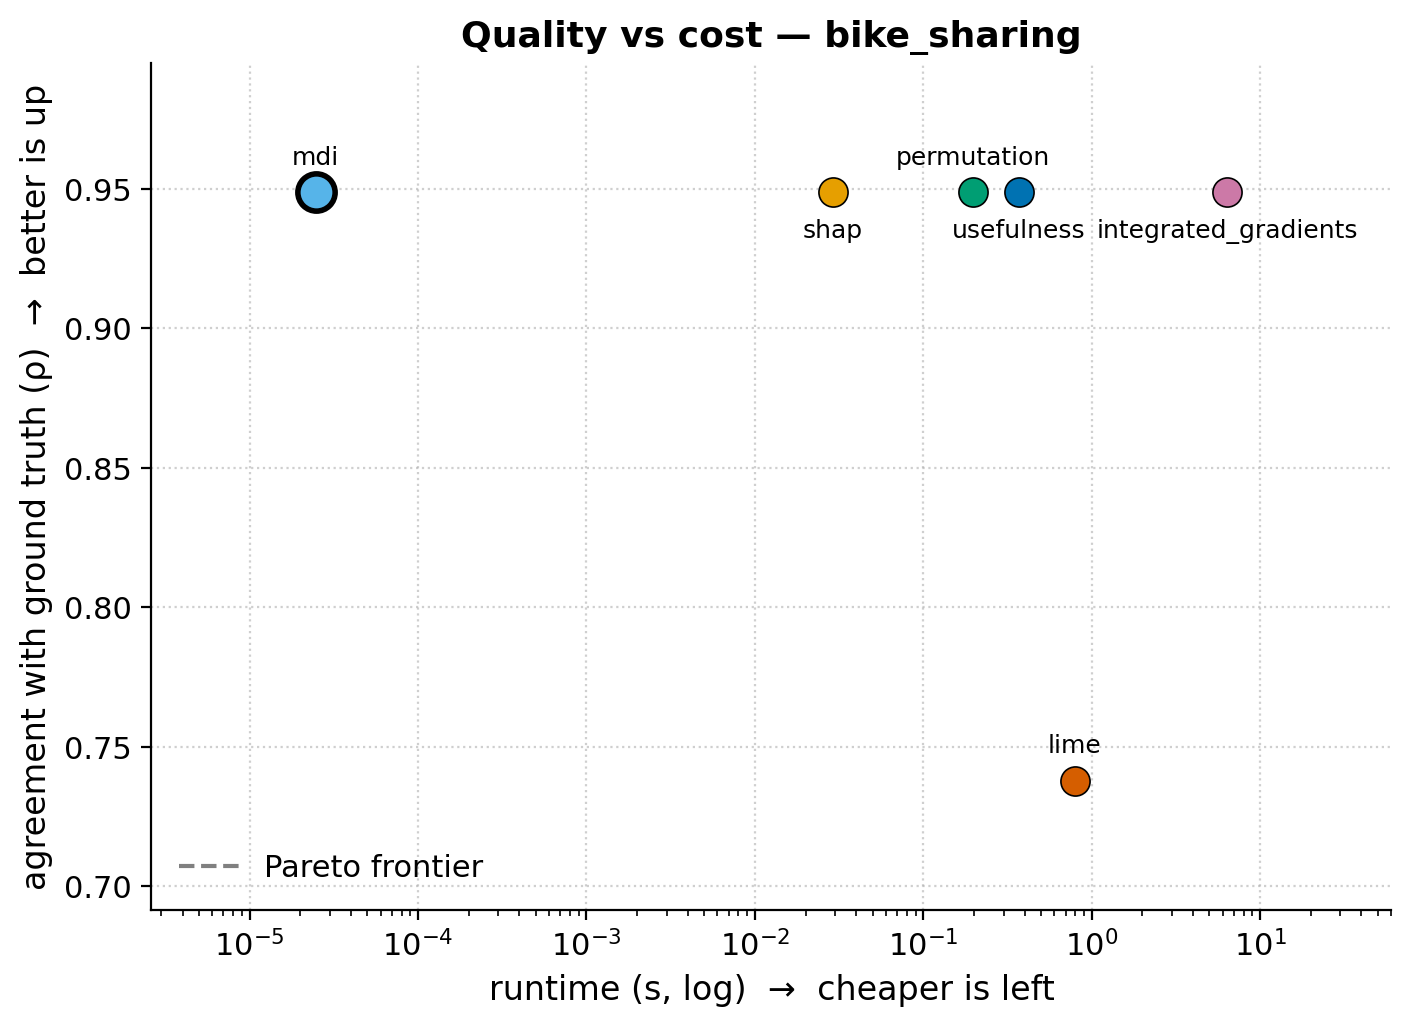

,method,time_s,spearman_gt
0,usefulness,0.3702,0.9487
1,mdi,0.0000,0.9487
2,permutation,0.1983,0.9487
3,shap,0.0292,0.9487
4,lime,0.7961,0.7379
5,integrated_gradients,6.3896,0.9487


In [33]:
# (d) quality vs cost (Pareto). Note: the y-axis can saturate when the ground
#     truth lists few features (e.g. Bike), so several methods tie on quality.
qc = ux.quality_cost_table(model, cfg, methods=METHODS)
ux.plot_quality_cost_pareto(qc, DATASET, f'{TAG}_quality_cost'); show(f'{TAG}_quality_cost')
qc.round(4)

## 4. Binning-strategy sensitivity

Re-run under `uniform` / `quantile` / `kmeans` discretisation and measure accuracy,
agreement with ground truth, and how much the induced ranking moves between strategies.

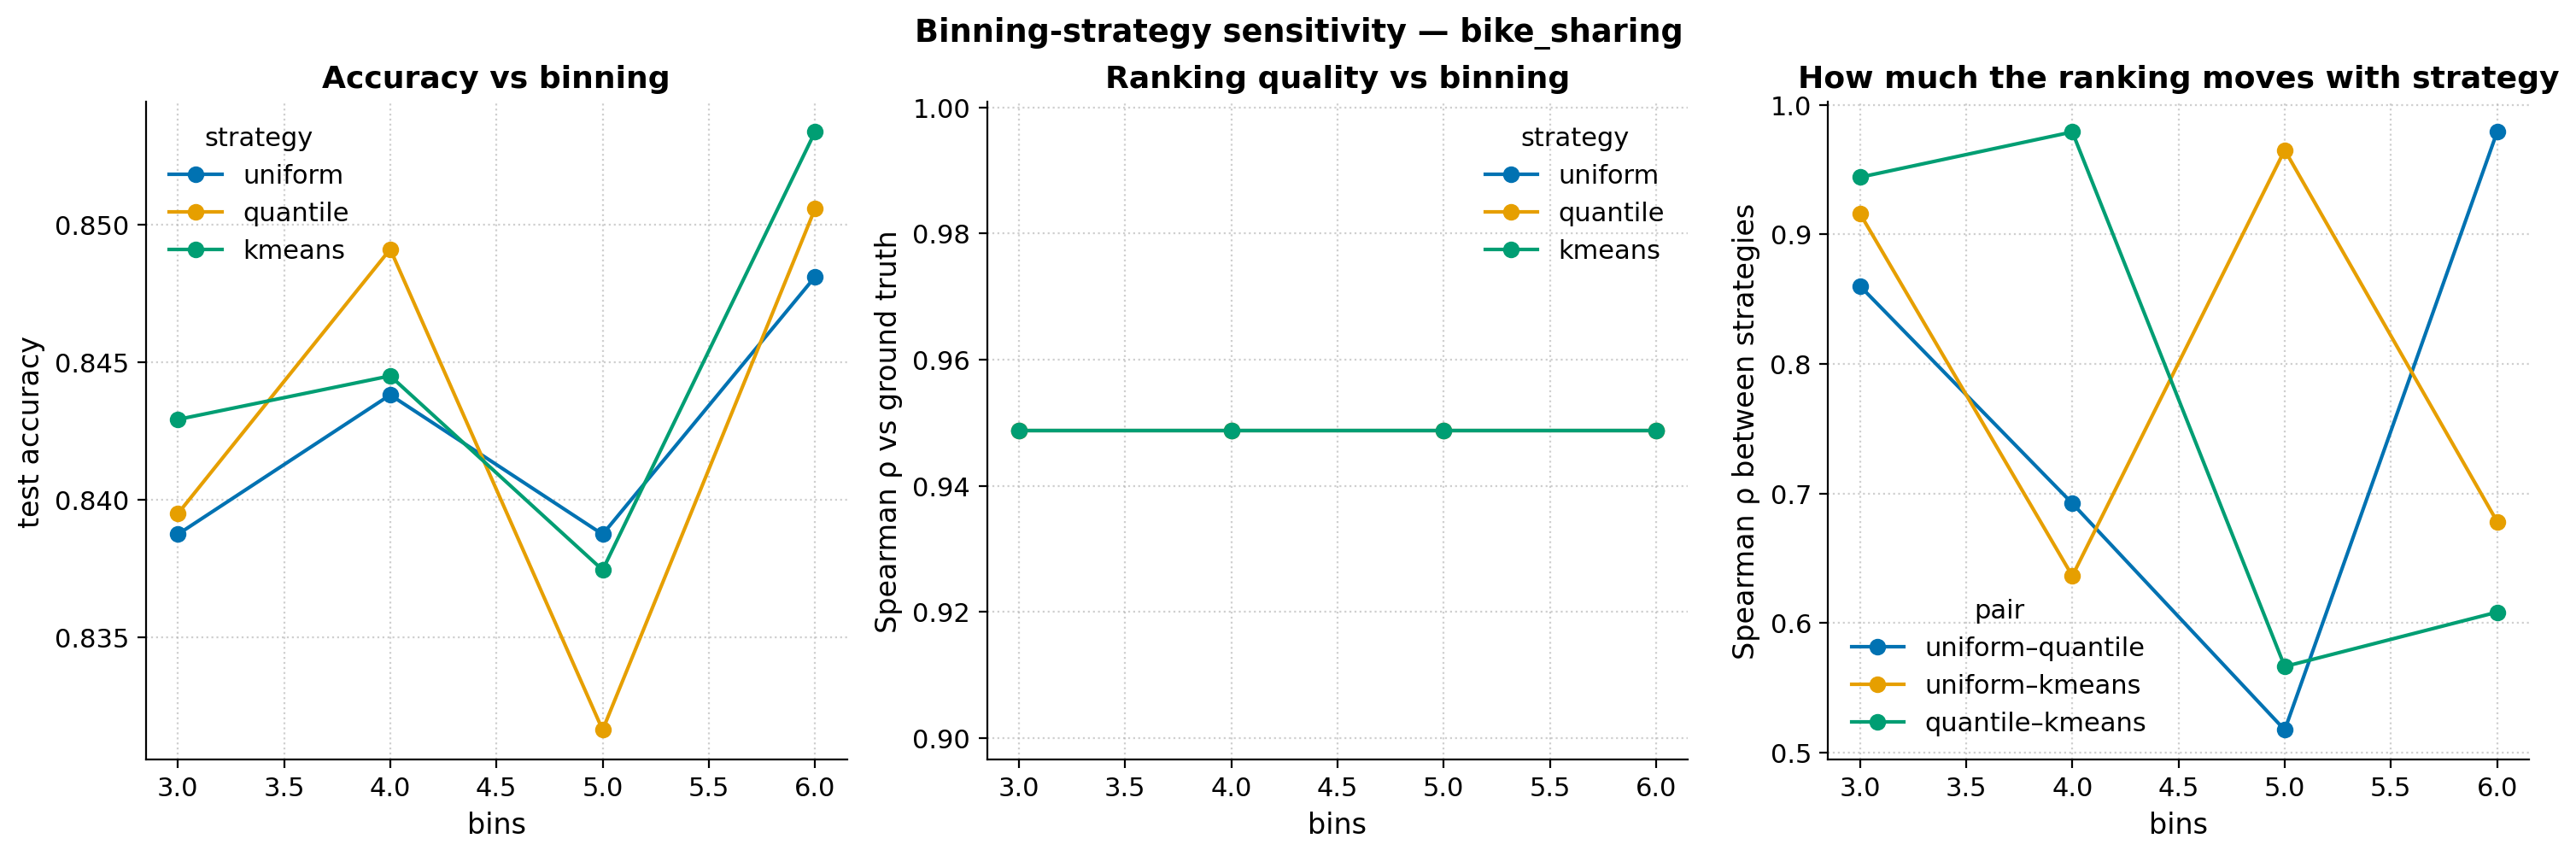

,dataset,strategy,bins,accuracy,spearman_gt,top1_hit,top3_recall
0,bike_sharing,uniform,3,0.839,0.949,1.0,1.0
1,bike_sharing,uniform,4,0.844,0.949,1.0,1.0
2,bike_sharing,uniform,5,0.839,0.949,1.0,1.0
3,bike_sharing,uniform,6,0.848,0.949,1.0,1.0
4,bike_sharing,quantile,3,0.839,0.949,1.0,1.0
5,bike_sharing,quantile,4,0.849,0.949,1.0,1.0
6,bike_sharing,quantile,5,0.832,0.949,1.0,1.0
7,bike_sharing,quantile,6,0.851,0.949,1.0,1.0
8,bike_sharing,kmeans,3,0.843,0.949,1.0,1.0
9,bike_sharing,kmeans,4,0.845,0.949,1.0,1.0


In [34]:
binning = ux.run_binning_experiment(DATASET, cfg, n_models=N_MODELS)
ux.plot_binning_sensitivity(binning, DATASET, f'{TAG}_binning')
show(f'{TAG}_binning')
binning['summary'].round(3)

## 5. Synthetic controlled-feature experiment (known ground truth)

Unlike the real datasets (whose ground truth is folklore), here the target
function is *known*, so the exact per-feature usefulness can be computed (with
our own score, on the tree that represents the target) and compared against the
trained model. Three planted groups: relevant, a redundant copy, and noise.

*This section is dataset-independent — it does not use `DATASET`.*

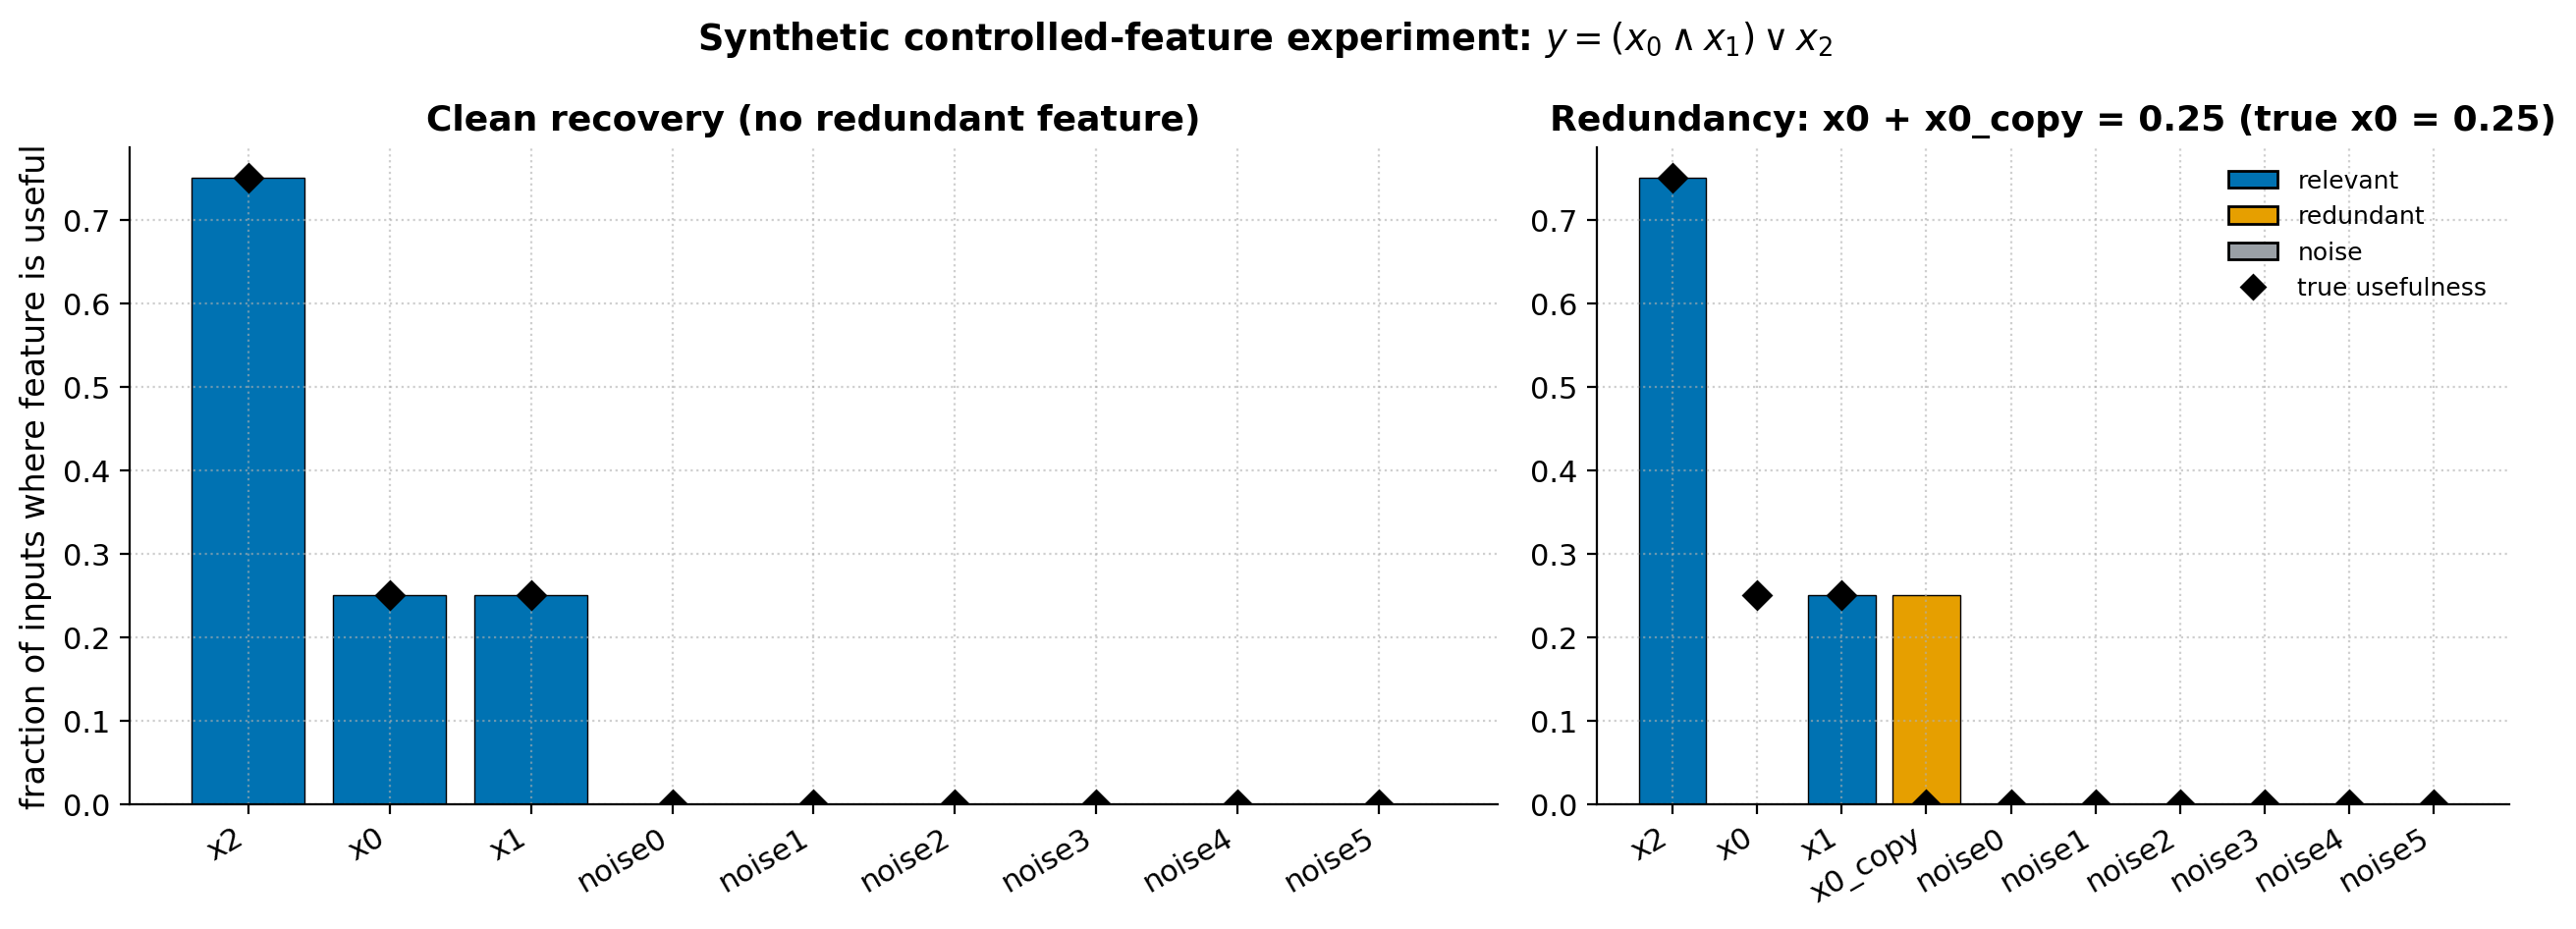

AUC (relevant vs noise) per method:


,auc_relevant_vs_noise
usefulness,1.0
mdi,1.0
permutation,1.0
shap,1.0
lime,1.0


redundancy (x0 mass moves to the copy the tree uses): {'x0': np.float64(0.0), 'x0_copy': np.float64(0.25), 'sum': np.float64(0.25), 'true_x0': 0.25}


In [35]:
syn = ux.run_synthetic_experiment(cfg, seed=42,
                                  methods=('usefulness', 'mdi', 'permutation', 'shap', 'lime'))
ux.plot_synthetic_recovery(syn, f'{RESULTS}/synthetic_recovery')
show(f'{RESULTS}/synthetic_recovery')
print('AUC (relevant vs noise) per method:')
display(syn['clean']['auc'][['auc_relevant_vs_noise']].round(3))
print('redundancy (x0 mass moves to the copy the tree uses):', syn['redundant']['redundancy'])

### The distribution-free property: a mode that SHAP under-reports

A multiplexer `y = x0 if x2=0 else x1` with a **rare** selector `x2`. Usefulness
(distribution-free) keeps `x1` and the selector `x2` essential; mean|SHAP|
(data-weighted) drops them toward the noise level because that mode is rare.

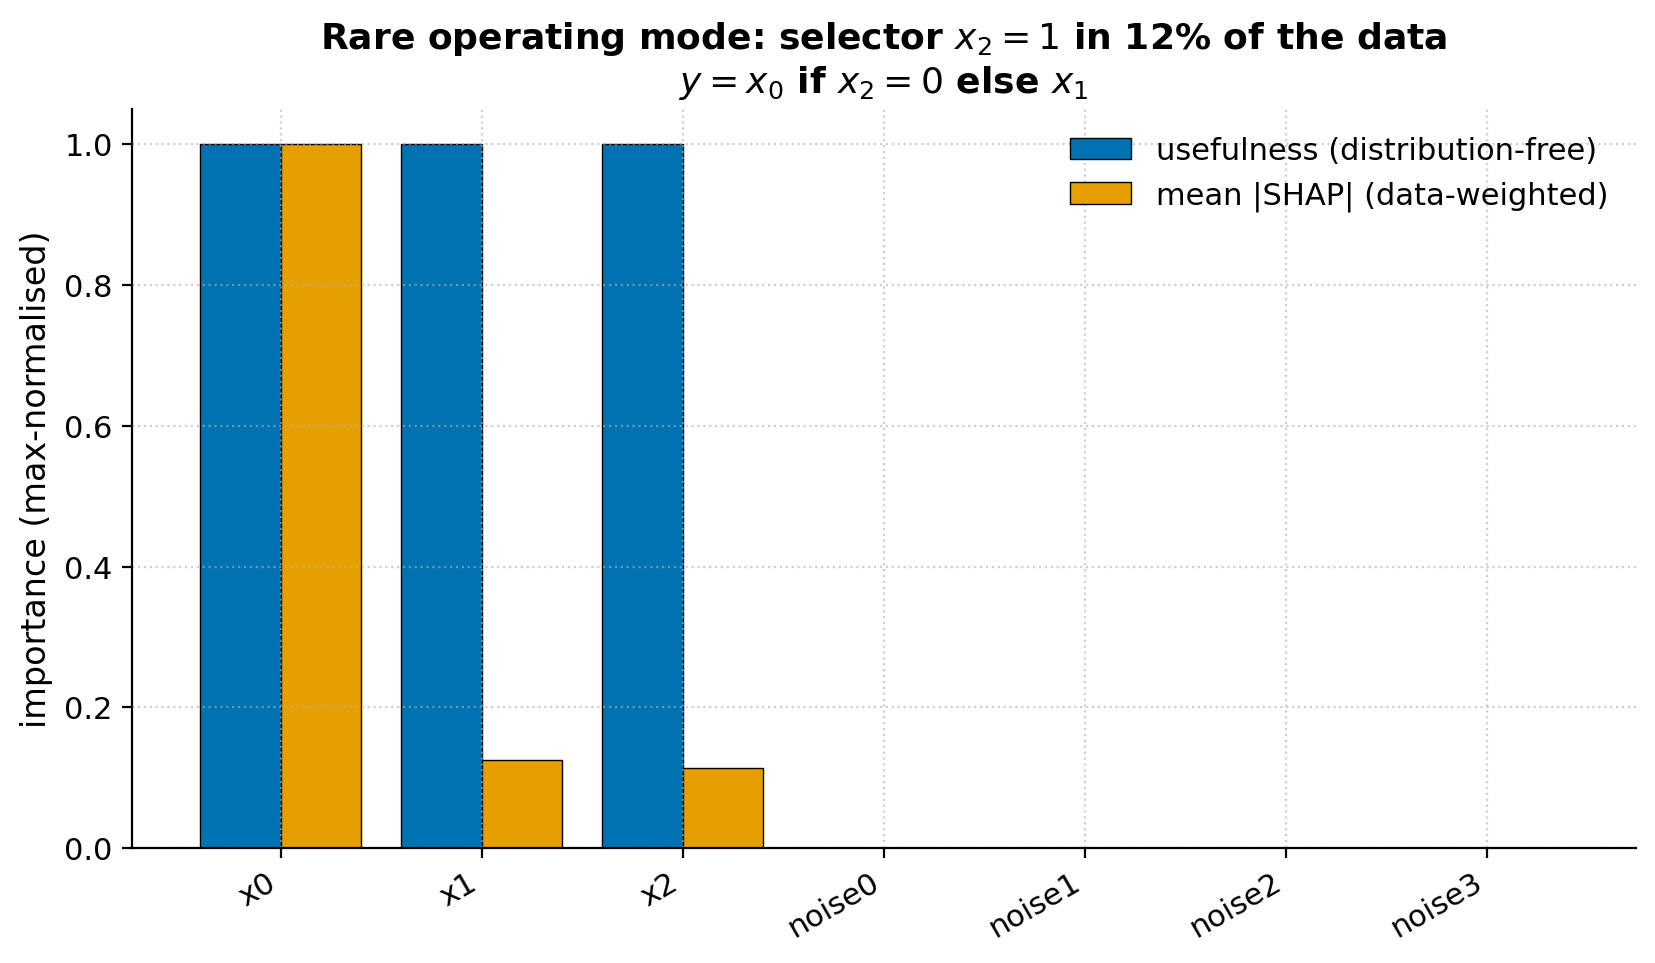

,feature,group,usefulness,shap
0,x0,relevant,1.0,1.000
1,x1,relevant,1.0,0.126
2,x2,relevant,1.0,0.114
3,noise0,noise,0.0,0.000
4,noise1,noise,0.0,0.000
5,noise2,noise,0.0,0.000
6,noise3,noise,0.0,0.000


In [36]:
rare = ux.run_rare_relevance_experiment(cfg, seed=42, skew=0.12)
ux.plot_rare_relevance(rare, f'{RESULTS}/synthetic_rare')
show(f'{RESULTS}/synthetic_rare')
rare['table'].round(3)

## Reproduce all three datasets

Set `DATASET` to `california` or `adult_income` above and *Run All*, or run everything
headless with the driver (identical results, no notebook state to worry about):

```bash
python experiments_driver.py --datasets california bike_sharing adult_income --n-models 20
```